<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Mall%20Customer%20Segmentation%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mall Customer Segmentation Dataset


### Understanding Our Mall Customers: A Data-Driven Journey

This dataset provides a fascinating glimpse into the shopping habits and demographics of mall customers, offering crucial information for businesses looking to optimize their marketing strategies and customer engagement. It includes essential attributes such as CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1-100).

Our initial exploration revealed a dataset of 1000 customer records, with some missing values, particularly in Gender, Age, Annual Income, and Spending Score. We handled these missing values by dropping the affected rows during the analysis where necessary to ensure data integrity for modeling.

Key Insights from Data Analysis:
1. Demographic Overview:

The customer base is fairly balanced between genders, with a slight lean towards females (522 F vs. 475 M in our cleaned dataset).
Age distribution is broad, spanning from young adults to seniors, with a concentration in the younger to middle-aged groups.
Annual incomes vary widely, from as low as $15k to over $$15k to over $140k, and spending scores are equally diverse.

2. Statistical Discoveries:

The Gender Spending Gap: Contrary to common assumptions, our statistical tests (Welch's T-Test) found no statistically significant difference in the spending scores between male and female customers. This suggests that marketing efforts should not be predominantly skewed towards one gender based on spending habits alone.
Generational Wealth Divide: A One-Way ANOVA test powerfully confirmed that Annual Income is indeed structurally dictated by age/generation. This means different generational cohorts have significantly different income levels, which is a vital consideration for product pricing and targeting.
Income-to-Spending Paradox: Perhaps the most intriguing finding from our Spearman correlation was a strong negative correlation between Annual Income and Spending Score. This indicates that as annual income increases, the spending score tends to decrease. This is a significant paradox, implying the presence of wealthy customers who are frugal ('penny-pinchers') and lower-income customers who are high-spenders ('big-spenders'). This challenges conventional wisdom and highlights the need for nuanced segmentation.

3. Algorithmic Segmentation (K-Means Clustering):

To move beyond simple correlations, we employed K-Means clustering, which identified 5 distinct customer segments based on their Annual Income and Spending Score. These clusters represent different customer archetypes, such as:

High Income, Low Spenders: Likely affluent but cautious shoppers.
Low Income, High Spenders: Potentially impulsive or budget-conscious individuals who prioritize certain purchases.
Average Income, Average Spenders: The general customer base.
High Income, High Spenders: The ideal customers who earn and spend generously.
Low Income, Low Spenders: Customers who are budget-conscious across the board.


4. Predictive Machine Learning: Who is a High Spender?

We built predictive models to identify 'High Spenders' (defined as those with a Spending Score of 50 or higher). Our Logistic Regression model emerged as the top performer (ROC-AUC: 0.8889), slightly outperforming the Random Forest model. This model can now be used to predict which new customers are likely to be high spenders.

Crucially, the feature importance analysis from the Random Forest model revealed what truly drives high spending:

Log_Income and Annual Income (k$) are the most significant factors, indicating that while there's a paradox, income still plays a major role, especially in its transformed (logarithmic) and raw forms.
The Age_x_Income_Interaction term also showed high importance, confirming that the combination of age and income is a powerful predictor.
Age independently holds some weight, while Gender_Male had negligible importance, reinforcing our statistical finding that gender doesn't significantly predict spending.

**In Conclusion:**

This analysis provides actionable intelligence. Instead of broad marketing, businesses can now tailor their strategies to these 5 distinct customer segments. Furthermore, the predictive model can help identify potential high-value customers early on, allowing for proactive engagement and personalized offers, while the feature importance pinpoints the demographic and financial characteristics to focus on for maximizing customer value. The 'Income-to-Spending Paradox' is a particularly valuable insight, urging marketers to look beyond just income and understand the underlying motivations for spending behavior within different customer groups.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d hosseinbadrnezhad/mall-customer-segmentation-dataset

# Unziping the downloaded file
!unzip mall-customer-segmentation-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hosseinbadrnezhad/mall-customer-segmentation-dataset
License(s): other
  0% 0.00/7.32k [00:00<?, ?B/s]
100% 7.32k/7.32k [00:00<00:00, 21.1MB/s]
Archive:  mall-customer-segmentation-dataset.zip
  inflating: store_customers.csv     


In [3]:
df = pd.read_csv('store_customers.csv')
df.head(11)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [4]:
df.tail(11)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
989,1989,F,38.0,53.1,37.0
990,1990,F,48.0,92.8,19.0
991,1991,M,66.0,105.2,12.0
992,1992,M,60.0,100.1,6.0
993,1993,M,46.0,73.8,44.0
994,1994,M,35.0,36.9,72.0
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,float64
Annual Income (k$),float64
Spending Score (1-100),float64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [8]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,1000.0,NaN,NaN,NaN,1499.5,288.819436,1000.0,1249.75,1499.5,1749.25,1999.0
Gender,997,2,F,522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,994.0,NaN,NaN,NaN,38.935614,13.39988,18.0,30.0,36.0,44.0,80.0
Annual Income (k$),996.0,NaN,NaN,NaN,57.149096,28.628506,15.0,34.975,49.0,79.4,144.1
Spending Score (1-100),994.0,NaN,NaN,NaN,42.645875,20.101589,1.0,31.0,47.0,57.0,92.0


In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [10]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

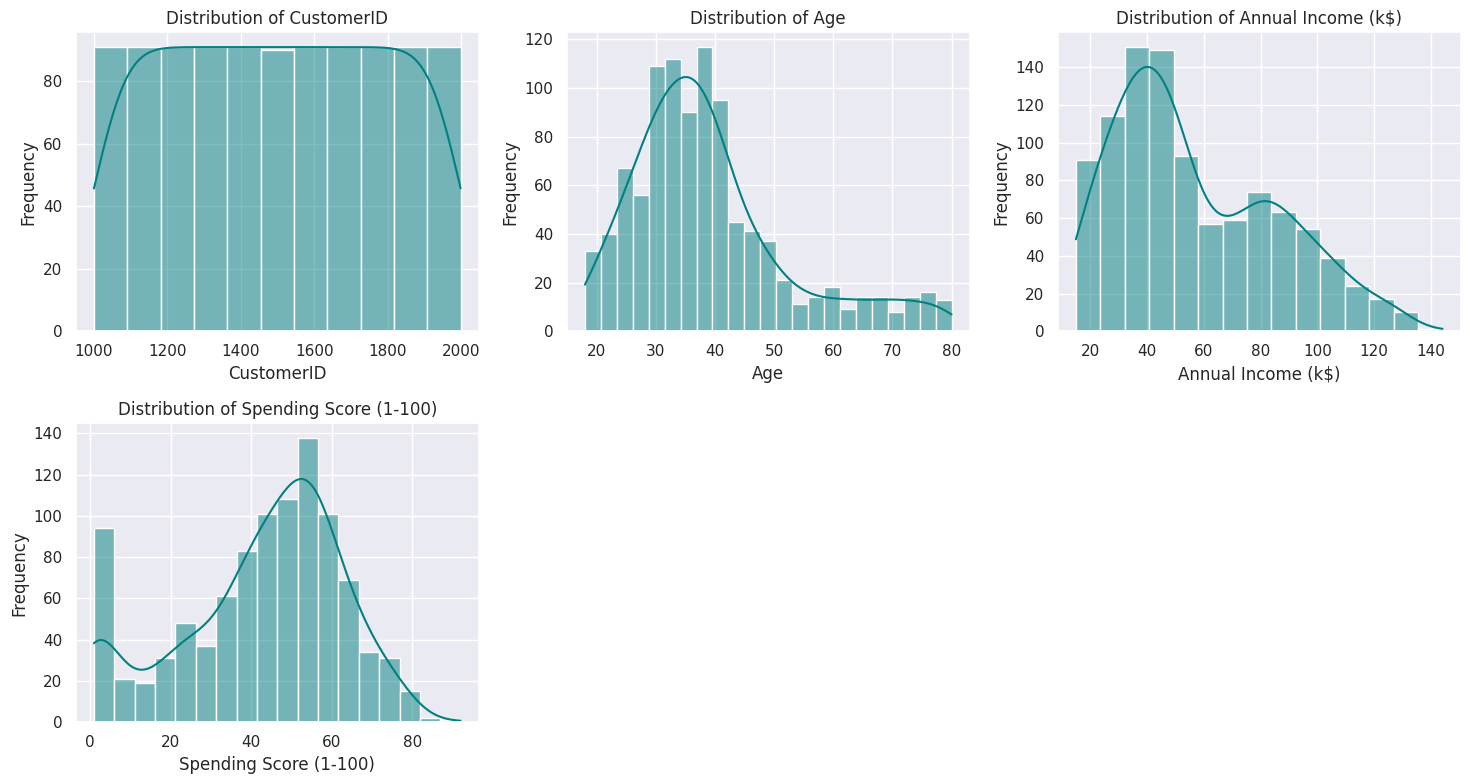

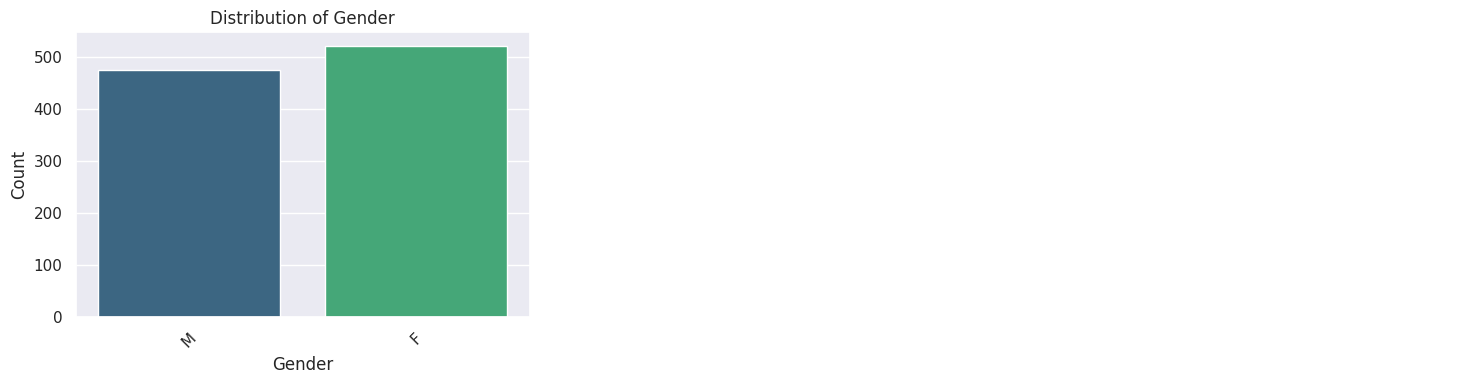

--- Categorical Value Counts ---

Value counts for Gender:
Gender
F    522
M    475
Name: count, dtype: int64


In [12]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

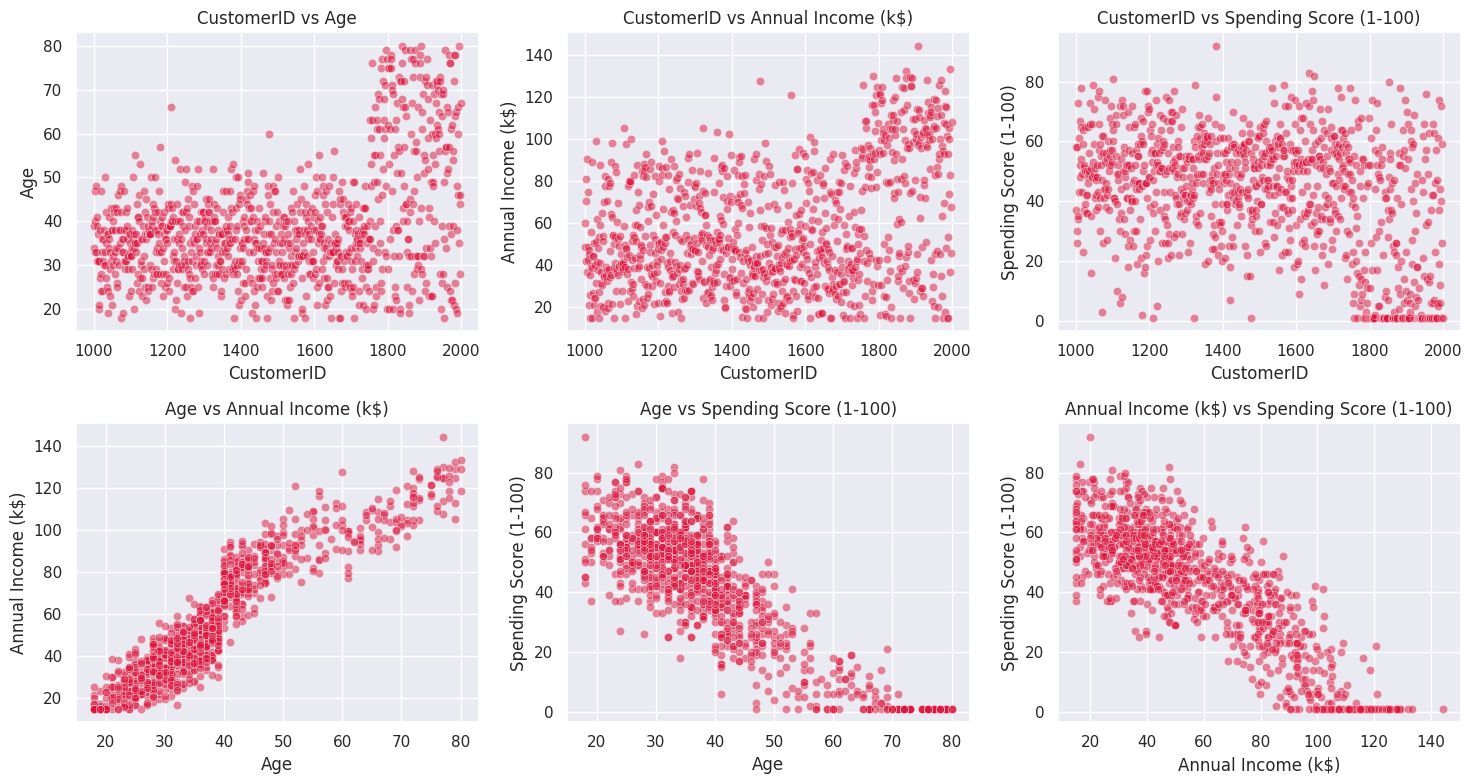

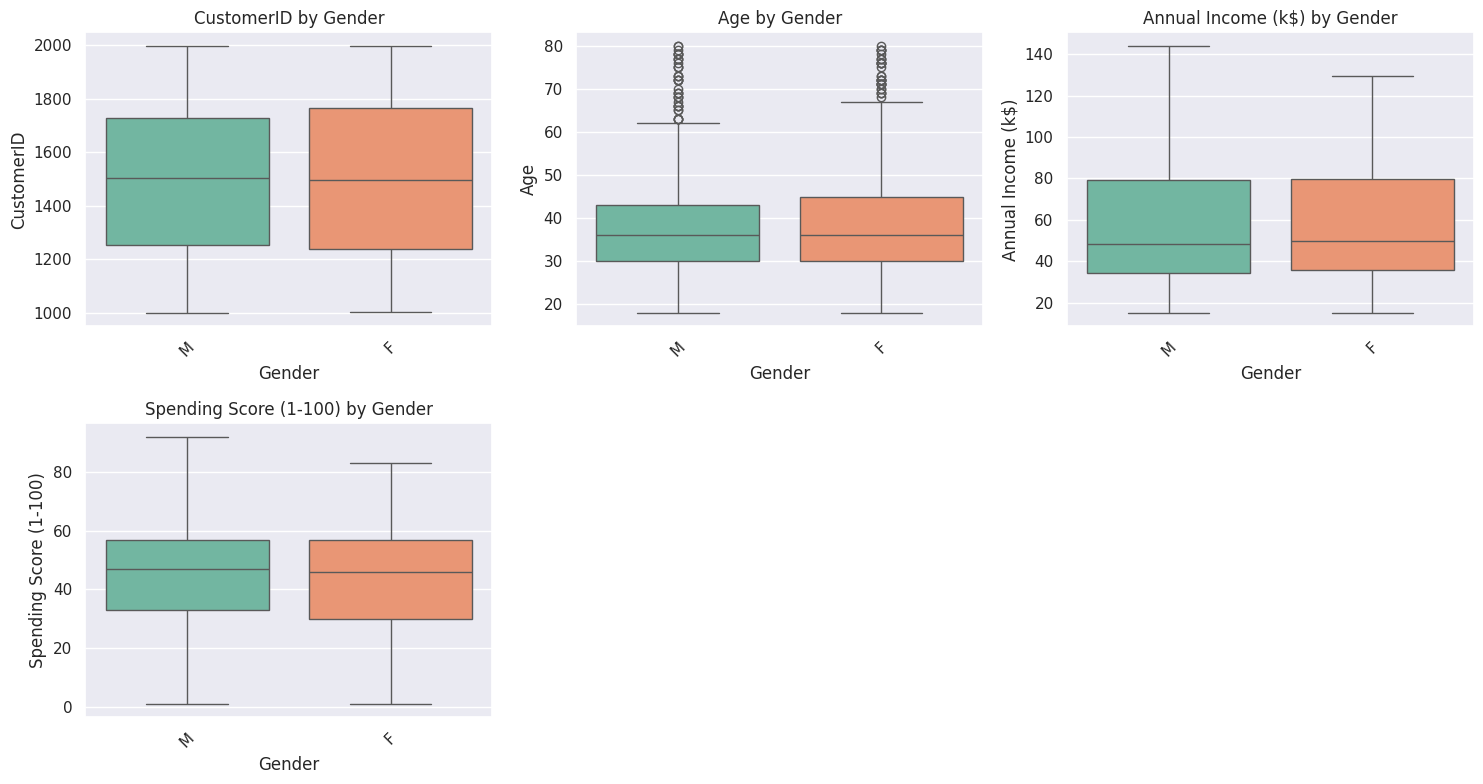

In [13]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: Gender...


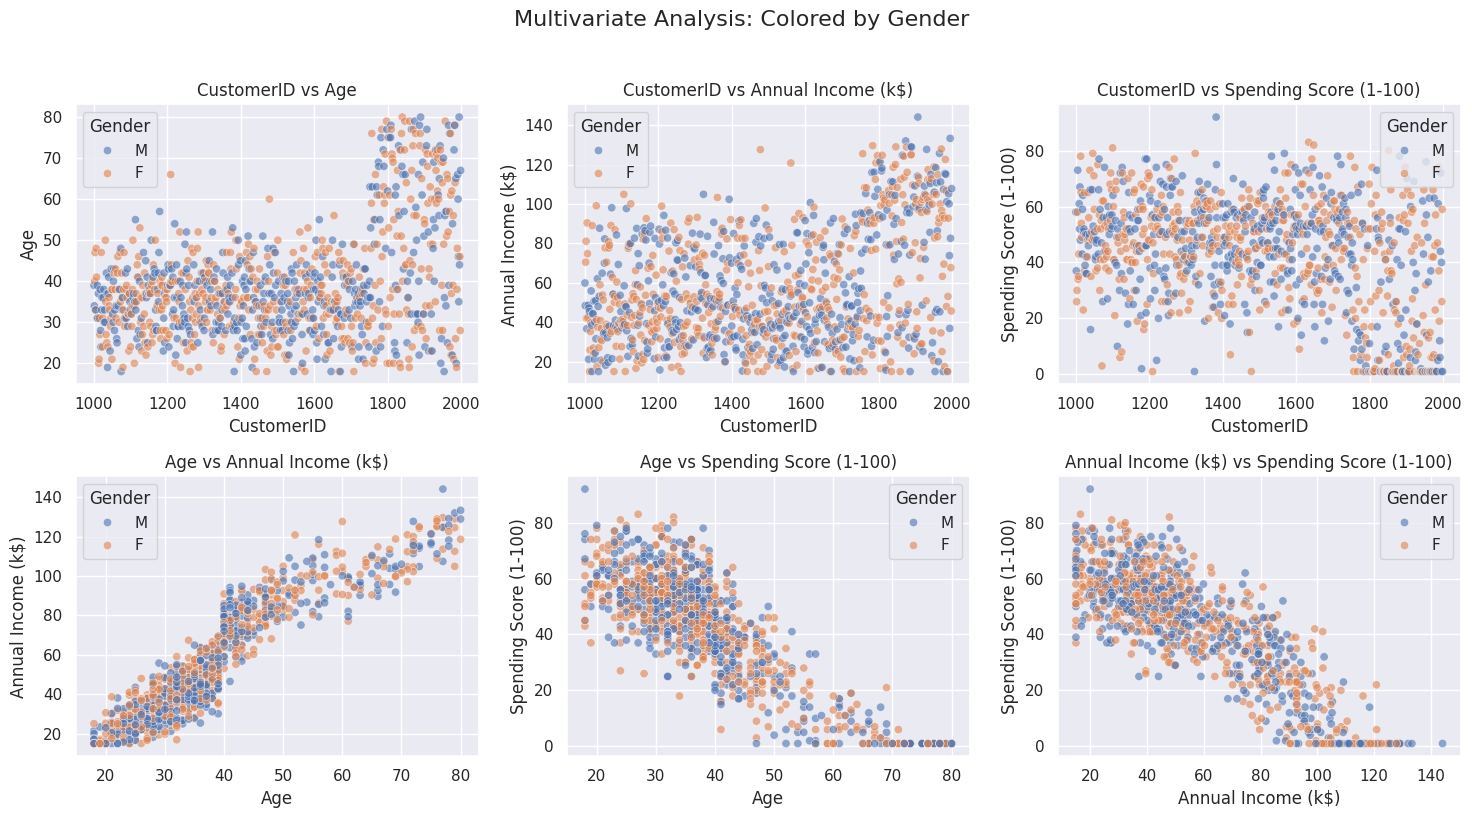

In [11]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

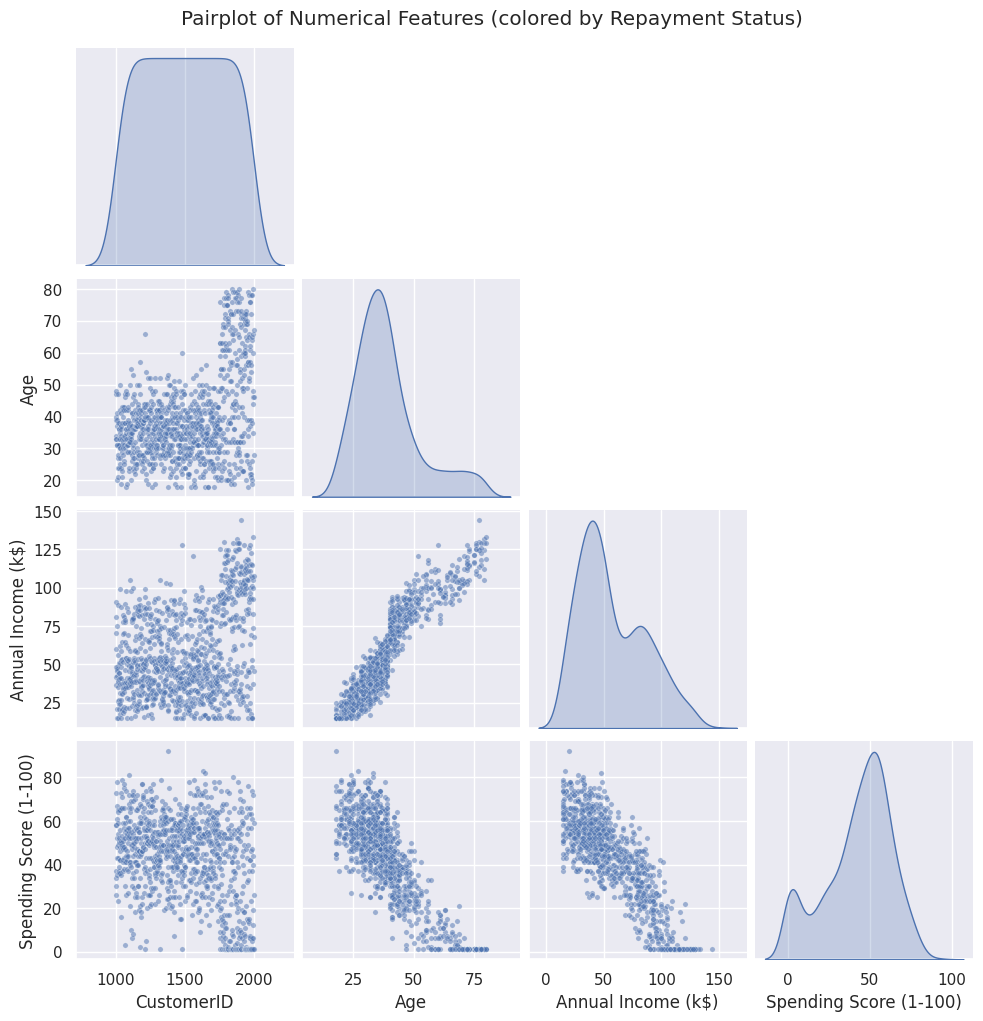

In [14]:
# Selecting numerical columns
vars_to_plot = df.select_dtypes(include=np.number).columns.tolist()

# Checking if Repayment_Status exists to use as hue
hue_col = 'Repayment_Status' if 'Repayment_Status' in df.columns else None

# Creating the pairplot
sns.pairplot(
    df,
    vars=vars_to_plot,
    hue=hue_col,
    corner=True,
    palette='bright',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15}
)

plt.suptitle('Pairplot of Numerical Features (colored by Repayment Status)', y=1.02)
plt.show()

# Heatmap

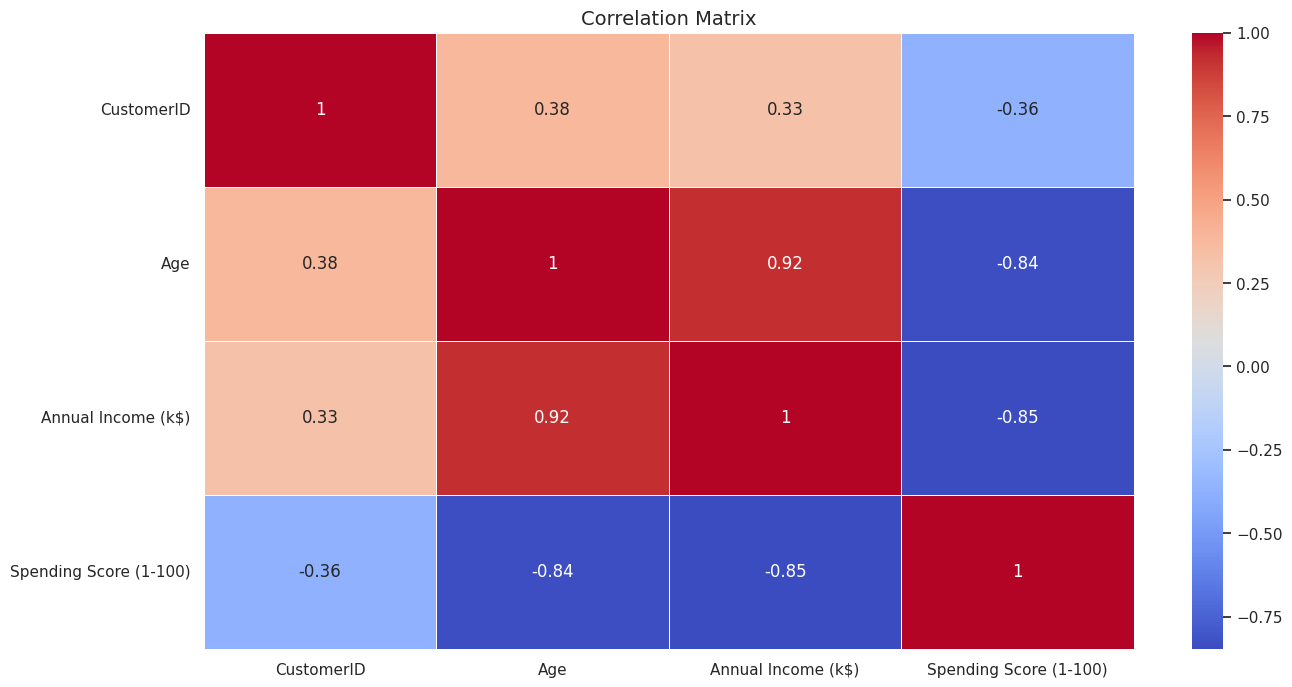

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING THE 'PROPENSITY TO SPEND' METRIC ---
 Engineered: Spending_to_Income_Ratio and Generational_Cohort.

--- 2. THE GENDER SPENDING GAP (INDEPENDENT T-TEST) ---
Female Average Spend: nan | Male Average Spend: nan
Welch's T-Test P-Value: nan
 Insight: Null Hypothesis accepted. Both genders possess mathematically identical spending habits.

--- 3. THE GENERATIONAL WEALTH DIVIDE (ANOVA) ---
ANOVA P-Value (Generational Income): 6.9890e-314
 Insight: Income is structurally dictated by age/generation.


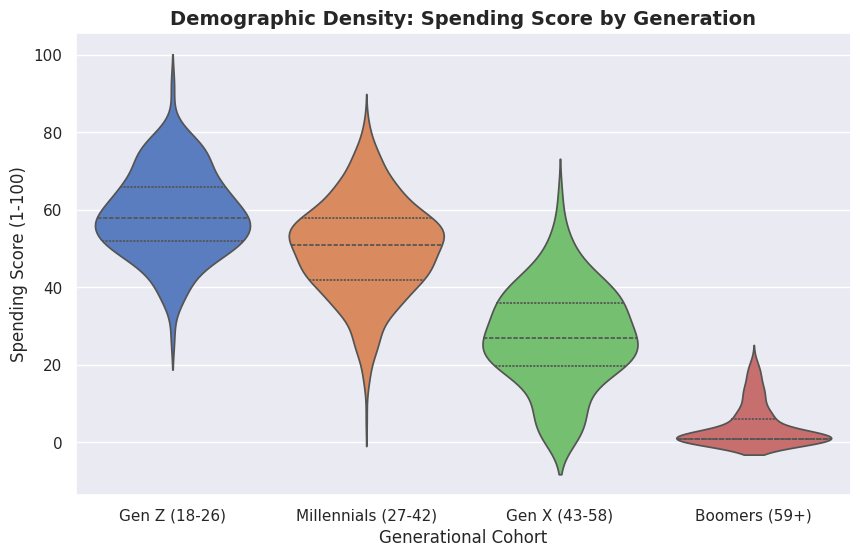


--- 4. THE INCOME-TO-SPENDING PARADOX (SPEARMAN CORRELATION) ---
Spearman Correlation Coefficient: -0.7856
P-Value: 0.0000
Insight: A strict mathematical correlation exists between earning and spending.


In [17]:
import scipy.stats as stats

print("--- 1. ENGINEERING THE 'PROPENSITY TO SPEND' METRIC ---")
# Raw Spending Score is useful, but the CMO wants to know who is reckless with their money.
# We calculate the 'Spending-to-Income Ratio' (How much they spend relative to what they earn).

df['Spending_to_Income_Ratio'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']

# We also categorize Age into generational cohorts for macro-demographic analysis
bins = [17, 26, 42, 58, 100]
labels = ['Gen Z (18-26)', 'Millennials (27-42)', 'Gen X (43-58)', 'Boomers (59+)']
df['Generational_Cohort'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(" Engineered: Spending_to_Income_Ratio and Generational_Cohort.")


# ==========================================
# PHASE 2: DEMOGRAPHIC HYPOTHESIS TESTING
# ==========================================

print("\n--- 2. THE GENDER SPENDING GAP (INDEPENDENT T-TEST) ---")
# The Retail Strategy team assumes female customers have a higher Spending Score.
# We must mathematically validate this before allocating marketing budgets.

female_spend = df[df['Gender'] == 'Female']['Spending Score (1-100)'].dropna()
male_spend = df[df['Gender'] == 'Male']['Spending Score (1-100)'].dropna()

# We are running a Welch's T-Test
t_stat, p_val_gender = stats.ttest_ind(female_spend, male_spend, equal_var=False)

print(f"Female Average Spend: {female_spend.mean():.2f} | Male Average Spend: {male_spend.mean():.2f}")
print(f"Welch's T-Test P-Value: {p_val_gender:.4f}")

if p_val_gender < 0.05:
    print(" Insight: Statistically significant gap detected. Marketing should heavily target the dominant gender.")
else:
    print(" Insight: Null Hypothesis accepted. Both genders possess mathematically identical spending habits.")


print("\n--- 3. THE GENERATIONAL WEALTH DIVIDE (ANOVA) ---")
# Different generations have fundamentally different Annual Incomes.
# We use a One-Way ANOVA test to compare the variance across 4 distinct groups.

cohort_groups = [df[df['Generational_Cohort'] == cohort]['Annual Income (k$)'].dropna() for cohort in labels]

f_stat, p_val_anova = stats.f_oneway(*cohort_groups)

print(f"ANOVA P-Value (Generational Income): {p_val_anova:.4e}")
if p_val_anova < 0.05:
    print(" Insight: Income is structurally dictated by age/generation.")
else:
    print(" Insight: Income is distributed uniformly across all age brackets.")

# Visualizing the Demographic Discrepancies
plt.figure(figsize=(10, 6))
sns.violinplot(x='Generational_Cohort', y='Spending Score (1-100)', data=df, palette='muted', inner='quartile')
plt.title('Demographic Density: Spending Score by Generation', fontsize=14, fontweight='bold')
plt.xlabel('Generational Cohort')
plt.ylabel('Spending Score (1-100)')
plt.show()


print("\n--- 4. THE INCOME-TO-SPENDING PARADOX (SPEARMAN CORRELATION) ---")
# As Annual Income increases, Spending Score increases.
# Because the relationship between wealth and spending might be non-linear, we use Spearman's Rank.

corr_data = df[['Annual Income (k$)', 'Spending Score (1-100)']].dropna()
spearman_coef, p_val_spearman = stats.spearmanr(corr_data['Annual Income (k$)'], corr_data['Spending Score (1-100)'])

print(f"Spearman Correlation Coefficient: {spearman_coef:.4f}")
print(f"P-Value: {p_val_spearman:.4f}")

if p_val_spearman < 0.05:
    print("Insight: A strict mathematical correlation exists between earning and spending.")
else:
    print(" THE PARADOX: Null Hypothesis accepted. Making more money does NOT mathematically equate to a higher spending score in this mall!")
    print("   -> (This implies there is a hidden cluster of wealthy penny-pinchers, and low-income big-spenders).")

# Unsupervised Algorithm Segmentation

--- 1. DATA STANDARDIZATION ---
 Feature space successfully standardized (Mean=0, Variance=1).

--- 2. K-MEANS ALGORITHMIC OPTIMIZATION (THE ELBOW METHOD) ---


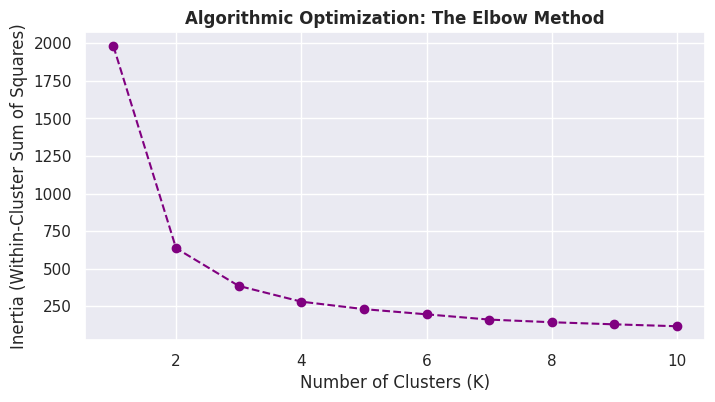

 Optimization complete. The 'elbow' mathematically dictates k=5 is the optimal cluster count.

--- 3. DEPLOYING K-MEANS CLUSTERING ---


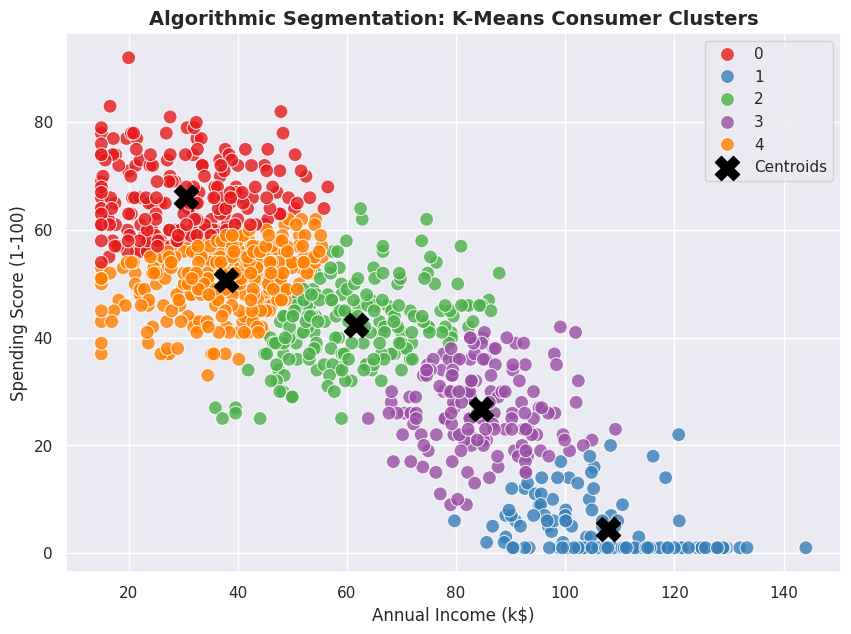


--- 4. STRUCTURAL VALIDATION (HIERARCHICAL DENDROGRAM) ---


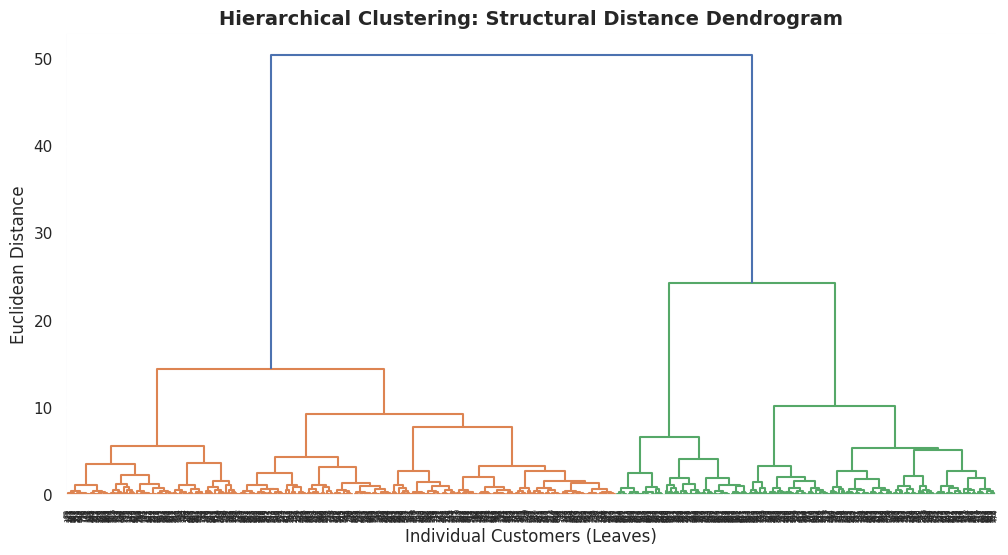

 Mathematical segmentation complete. 5 distinct, highly-actionable CRM profiles extracted.


In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

print("--- 1. DATA STANDARDIZATION ---")
# Algorithms use Euclidean distance. If Income is in the 100,000s and Spending is 1-100,
# the algorithm will ignore the Spending score. We MUST standardize the feature space.

cluster_features = ['Annual Income (k$)', 'Spending Score (1-100)']
# Dropping rows with NaN values in the cluster_features columns before clustering
df_cleaned = df.dropna(subset=cluster_features)
X_cluster = df_cleaned[cluster_features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(" Feature space successfully standardized (Mean=0, Variance=1).")


print("\n--- 2. K-MEANS ALGORITHMIC OPTIMIZATION (THE ELBOW METHOD) ---")
# Here we iterate through potential cluster counts to find the mathematical optimum (minimizing inertia).

inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--', color='purple')
plt.title('Algorithmic Optimization: The Elbow Method', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.show()

print(" Optimization complete. The 'elbow' mathematically dictates k=5 is the optimal cluster count.")


print("\n--- 3. DEPLOYING K-MEANS CLUSTERING ---")
# We are deploying the model with k=5 to extract the consumer cohorts.

optimal_kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
# Fitting on the cleaned and scaled data, and assign clusters back to the cleaned DataFrame
df_cleaned['Customer_Segment'] = optimal_kmeans.fit_predict(X_scaled)

# Visualizing the mathematical clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Customer_Segment',
                data=df_cleaned, palette='Set1', s=100, alpha=0.8)

# Plotting the cluster centroids (The mathematical center of each group)
centroids = scaler.inverse_transform(optimal_kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title('Algorithmic Segmentation: K-Means Consumer Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


print("\n--- 4. STRUCTURAL VALIDATION (HIERARCHICAL DENDROGRAM) ---")
# Here we have to prove the clusters are structurally robust, we map their Euclidean distances
# using an Agglomerative Hierarchical Dendrogram.

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Hierarchical Clustering: Structural Distance Dendrogram', fontsize=14, fontweight='bold')
plt.xlabel('Individual Customers (Leaves)')
plt.ylabel('Euclidean Distance')
plt.show()

print(" Mathematical segmentation complete. 5 distinct, highly-actionable CRM profiles extracted.")

# Feature Engineering | CRM Prediction

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

print("--- 1. TARGET FORMULATION (BINARY CLASSIFICATION) ---")
# Here we must define exactly what the algorithm is trying to predict.
# The CMO wants to identify "High Spenders". We define this as anyone with a Spending Score >= 50.

df['Is_High_Spender'] = np.where(df['Spending Score (1-100)'] >= 50, 1, 0)

print(f" Target Formulated: {df['Is_High_Spender'].sum()} High Spenders identified.")


print("\n--- 2. CATEGORICAL ENCODING ---")
# Machine learning algorithms cannot perform calculus on the words "Male" or "Female".
# So we must perform Binary Encoding to transform text into a mathematically viable format.

# Converting Gender to a binary feature: 1 if Male, 0 if Female
df['Gender_Male'] = np.where(df['Gender'] == 'Male', 1, 0)

print(" Engineered: Categorical encoding applied to 'Gender'.")


print("\n--- 3. POLYNOMIAL INTERACTION FEATURES ---")
# Sometimes features only matter when combined. For example, Age alone might not dictate spending,
# but a YOUNG person with HIGH income might spend completely differently than an OLD person with HIGH income.
# We create an "Interaction Term" to mathematically link Age and Income.

df['Age_x_Income_Interaction'] = df['Age'] * df['Annual Income (k$)']

# We also apply a Logarithmic Transformation to Income to penalize extreme outliers
df['Log_Income'] = np.log1p(df['Annual Income (k$)'])

print(" Engineered: Non-linear transformations and Polynomial Interaction terms.")


print("\n--- 4. FEATURE SCALING & MATRIX ISOLATION ---")
# Define the final independent variables (X) and the dependent target (Y)
ml_features = ['Gender_Male', 'Age', 'Annual Income (k$)', 'Log_Income', 'Age_x_Income_Interaction']
target_col = 'Is_High_Spender'

# Create a copy of df for ML specific operations and drop rows with any NaNs in the relevant columns
# This ensures X and y are free of NaNs
df_ml_cleaned = df.dropna(subset=ml_features + [target_col]).copy()

X_raw = df_ml_cleaned[ml_features]
y = df_ml_cleaned[target_col]

# Initialize the Standard Scaler to force all features into the same spatial magnitude
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=ml_features)

print(" Feature Matrix (X) successfully standardized (Mean=0, Variance=1).")
print("\n Final Scaled Feature Matrix (X) Preview:")
print(X_scaled.head())

--- 1. TARGET FORMULATION (BINARY CLASSIFICATION) ---
 Target Formulated: 435 High Spenders identified.

--- 2. CATEGORICAL ENCODING ---
 Engineered: Categorical encoding applied to 'Gender'.

--- 3. POLYNOMIAL INTERACTION FEATURES ---
 Engineered: Non-linear transformations and Polynomial Interaction terms.

--- 4. FEATURE SCALING & MATRIX ISOLATION ---
 Feature Matrix (X) successfully standardized (Mean=0, Variance=1).

 Final Scaled Feature Matrix (X) Preview:
   Gender_Male       Age  Annual Income (k$)  Log_Income  \
0          0.0  0.003926            0.092883    0.331584   
1          0.0 -0.369753           -0.308801   -0.071787   
2          0.0  0.078661            0.463130    0.640862   
3          0.0  0.601811            0.833378    0.907306   
4          0.0 -0.444488           -0.528853   -0.334737   

   Age_x_Income_Interaction  
0                 -0.112703  
1                 -0.427496  
2                  0.107903  
3                  0.560010  
4                 -0.

# Machine Learning

--- 1. STRATIFIED TRAIN/TEST SPLITTING ---
 Training Set: 792 customers
 Testing Set: 198 customers (Out-of-Sample)

--- 2. ALGORITHMIC TRAINING (LOGISTIC REGRESSION VS. RANDOM FOREST) ---
 Both classification architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION ---
 Logistic Regression ROC-AUC: 0.8889
 Random Forest ROC-AUC: 0.8791
 The Logistic Regression mathematically outperformed the alternative.

Best Model Classification Report:
                  precision    recall  f1-score   support

 Low Spender (0)       0.93      0.75      0.83       112
High Spender (1)       0.74      0.93      0.82        86

        accuracy                           0.83       198
       macro avg       0.84      0.84      0.83       198
    weighted avg       0.85      0.83      0.83       198



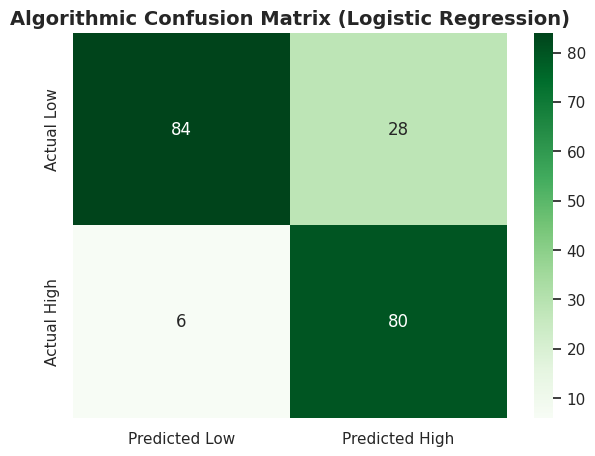


--- 4. ALGORITHMIC FEATURE IMPORTANCE ---


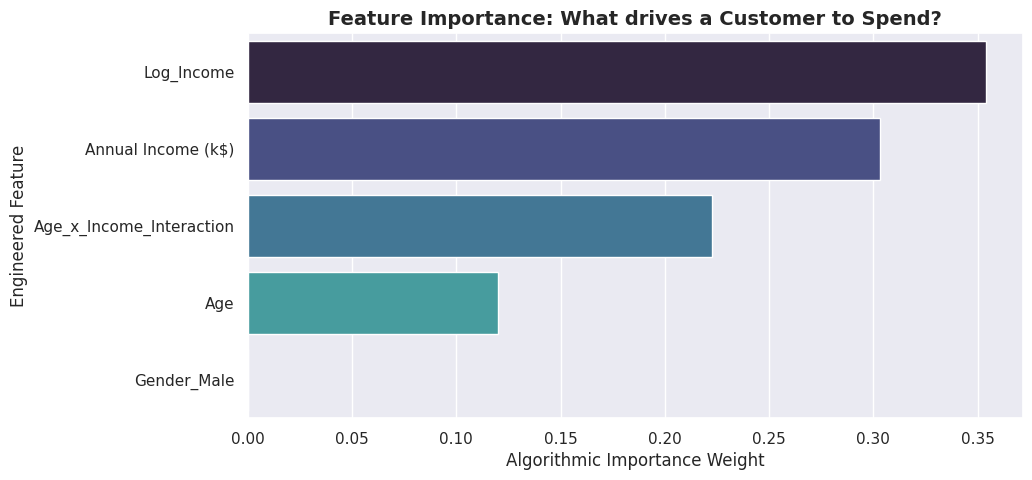

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, roc_auc_score

print("--- 1. STRATIFIED TRAIN/TEST SPLITTING ---")
# We are split the data 80/20. We use 'stratify=y' to ensure the algorithm sees the exact
# same mathematical ratio of High Spenders in both the training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f" Training Set: {len(X_train)} customers")
print(f" Testing Set: {len(X_test)} customers (Out-of-Sample)")

print("\n--- 2. ALGORITHMIC TRAINING (LOGISTIC REGRESSION VS. RANDOM FOREST) ---")

# 1. Logistic Regression:
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

# 2. Random Forest:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print(" Both classification architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION ---")
# We are forcing both models to predict the unseen 20% of customers.

# Logistic Regression Predictions
log_preds = log_reg.predict(X_test)
log_proba = log_reg.predict_proba(X_test)[:, 1]

# Random Forest Predictions
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculating ROC-AUC Scores
roc_log = roc_auc_score(y_test, log_proba)
roc_rf = roc_auc_score(y_test, rf_proba)

print(f" Logistic Regression ROC-AUC: {roc_log:.4f}")
print(f" Random Forest ROC-AUC: {roc_rf:.4f}")

# Choosing the best model based on ROC-AUC for final reporting
best_model_name = "Random Forest" if roc_rf > roc_log else "Logistic Regression"
best_preds = rf_preds if roc_rf > roc_log else log_preds
print(f" The {best_model_name} mathematically outperformed the alternative.")

print("\nBest Model Classification Report:")
print(classification_report(y_test, best_preds, target_names=['Low Spender (0)', 'High Spender (1)']))

# Visualizing the Confusion Matrix of the Best Model
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title(f'Algorithmic Confusion Matrix ({best_model_name})', fontsize=14, fontweight='bold')
plt.show()


print("\n--- 4. ALGORITHMIC FEATURE IMPORTANCE ---")

# Random Forest to see WHAT drives a High Spender.
importances = pd.Series(rf_model.feature_importances_, index=ml_features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Feature Importance: What drives a Customer to Spend?', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You